In [1]:
"""
signal_analysis2.ipynb — UPDATED to journal-entry level
---------------------------------------------------------
Previously: 1 row = 1 feature measurement  (940 rows → mismatches Tab 3)
Now:        1 row = 1 journal entry         (369 rows → matches Tab 3 grain)

Unit of analysis: one row = one journal entry for one domain.
Improvement flag: behavioral_improvement (yes/no) from task3_1_fixed output,
which uses z-score normalized composite signal with domain-specific direction.

This ensures counts are directly comparable to analysis2_0 (Tab 3).

Input files:
  feature_long_format2.csv          — for feature-level metadata + continuous change
  prompts_with_signals_task3_3day.csv — for journal-entry-level improvement flag

Output files:
  entry_level_stats_overall.csv     — overall INTENTION vs REFLECTION
  entry_level_stats_domain.csv      — per-domain INTENTION vs REFLECTION
"""

import numpy as np
import pandas as pd
from scipy.stats import fisher_exact, mannwhitneyu

# ── Load ──────────────────────────────────────────────────────────────────────
feat_df   = pd.read_csv('feature_long_format2.csv')
task3_df  = pd.read_csv('prompts_with_signals_task3_3day.csv')

print(f"feature_long_format2 rows : {len(feat_df)}")
print(f"task3_3day rows           : {len(task3_df)}")
print(f"Columns in task3_df: {task3_df.columns.tolist()}")

# ── Step 1: Build entry-level dataframe ──────────────────────────────────────
# One row per (participant_id, date, domain) from feature_long_format2
# Pick first occurrence for categorical columns (they're the same per entry)
entry_meta = (
    feat_df.groupby(['participant_id', 'date', 'domain'])
    .agg(
        response_type  =('response_type', 'first'),
        prompt_type    =('prompt_type',   'first'),
        mean_raw_change=('change',        'mean'),   # mean raw change across features
        n_features     =('feature',       'count'),
    )
    .reset_index()
)

print(f"\nEntry-level rows (before merge): {len(entry_meta)}")

# ── Step 2: Merge in behavioral_improvement from task3_1_fixed ───────────────
# task3 uses participant_id + date + behavioral_domain_category
task3_cols = task3_df[[
    'participant_id', 'date', 'behavioral_domain_category',
    'behavioral_improvement', 'signal_before', 'signal_after', 'signal_change'
]].copy()
task3_cols['date'] = pd.to_datetime(task3_cols['date']).dt.strftime('%Y-%m-%d')
entry_meta['date'] = pd.to_datetime(entry_meta['date']).dt.strftime('%Y-%m-%d')

df = entry_meta.merge(
    task3_cols,
    left_on  =['participant_id', 'date', 'domain'],
    right_on =['participant_id', 'date', 'behavioral_domain_category'],
    how='left'
)

print(f"Entry-level rows (after merge): {len(df)}")
print(f"behavioral_improvement NaN: {df['behavioral_improvement'].isna().sum()}")

# ── Step 3: Filter — keep only INTENTION and REFLECTION ──────────────────────
df = df[df['response_type'].isin(['INTENTION', 'REFLECTION'])].copy()
df['improved_bin'] = (df['behavioral_improvement'] == 'yes').astype(int)

print(f"\nAfter dropping NOT_APPLICABLE: {len(df)} entry-level rows")
print(f"  INTENTION : {(df['response_type']=='INTENTION').sum()}")
print(f"  REFLECTION: {(df['response_type']=='REFLECTION').sum()}")

DOMAINS = ['digital_habits', 'social_interaction', 'sleep', 'physical_fitness']


# ── Helper functions ──────────────────────────────────────────────────────────
def odds_ratio_ci(a_yes, a_no, b_yes, b_no, z=1.96):
    if min(a_yes, a_no, b_yes, b_no) == 0:
        a_yes+=0.5; a_no+=0.5; b_yes+=0.5; b_no+=0.5
    if b_yes == 0 or a_no == 0:
        return np.nan, np.nan, np.nan
    or_val  = (a_yes * b_no) / (a_no * b_yes)
    log_or  = np.log(or_val)
    se      = np.sqrt(1/a_yes + 1/a_no + 1/b_yes + 1/b_no)
    return round(or_val,3), round(np.exp(log_or-z*se),3), round(np.exp(log_or+z*se),3)


def rank_biserial_r(u_stat, n1, n2):
    return round(1 - (2 * u_stat) / (n1 * n2), 3)


def run_tests(A, B, label):
    """
    A, B: sub-DataFrames for INTENTION and REFLECTION at entry level.
    Uses improved_bin for Fisher's, signal_change for Mann-Whitney U.
    """
    na, nb = len(A), len(B)
    ay = int(A['improved_bin'].sum()); an = na - ay
    by = int(B['improved_bin'].sum()); bn = nb - by

    pct_a = ay/na*100 if na > 0 else np.nan
    pct_b = by/nb*100 if nb > 0 else np.nan

    _, fp = fisher_exact([[ay, an], [by, bn]])
    or_val, ci_lo, ci_hi = odds_ratio_ci(ay, an, by, bn)

    # Mann-Whitney on signal_change (composite z-score change from task3)
    ca = A['signal_change'].dropna()
    cb = B['signal_change'].dropna()
    if len(ca) >= 2 and len(cb) >= 2:
        u_stat, mp = mannwhitneyu(ca, cb, alternative='two-sided')
        rb_r = rank_biserial_r(u_stat, len(ca), len(cb))
    else:
        u_stat, mp, rb_r = np.nan, np.nan, np.nan

    sig_f = fp < 0.05
    sig_m = (not np.isnan(mp)) and mp < 0.05

    print(f"\n{'-'*65}")
    print(f"  {label}")
    print(f"  INTENTION  (A): N={na:>4} | improved {ay}/{na} = {pct_a:.1f}%")
    print(f"  REFLECTION (B): N={nb:>4} | improved {by}/{nb} = {pct_b:.1f}%")
    print(f"  signal_change — median A={ca.median():+.4f}  B={cb.median():+.4f}")
    print(f"\n  Fisher's exact : p = {fp:.4f}  {'← SIGNIFICANT' if sig_f else 'n.s.'}")
    print(f"  Odds ratio     : OR = {or_val}  95% CI [{ci_lo}, {ci_hi}]")
    if not np.isnan(mp):
        print(f"  Mann-Whitney U : p = {mp:.4f}  {'← SIGNIFICANT' if sig_m else 'n.s.'}  | rank-biserial r = {rb_r}")
    else:
        print(f"  Mann-Whitney U : insufficient data")

    return {
        'label': label,
        'n_intention': na, 'n_reflection': nb,
        'intention_improved': ay, 'reflection_improved': by,
        'intention_pct': round(pct_a,1), 'reflection_pct': round(pct_b,1),
        'fisher_p': round(fp,4), 'fisher_sig': sig_f,
        'odds_ratio': or_val, 'or_ci_lo': ci_lo, 'or_ci_hi': ci_hi,
        'mannwhitney_p': round(mp,4) if not np.isnan(mp) else np.nan,
        'mannwhitney_sig': sig_m,
        'rank_biserial_r': rb_r,
    }


# ══ LEVEL 1 — OVERALL ════════════════════════════════════════════════════════
print("\n" + "="*65)
print("LEVEL 1 — OVERALL: INTENTION (A) vs REFLECTION (B)")
print("="*65)
print("Unit: 1 row = 1 journal entry (composite z-score improvement flag)")

A_all = df[df['response_type']=='INTENTION']
B_all = df[df['response_type']=='REFLECTION']
overall = run_tests(A_all, B_all, 'All domains combined')

# ══ LEVEL 2 — BY DOMAIN ══════════════════════════════════════════════════════
print("\n\n" + "="*65)
print("LEVEL 2 — BY DOMAIN: INTENTION (A) vs REFLECTION (B)")
print("="*65)

domain_results = []
for domain in DOMAINS:
    sub = df[df['domain']==domain]
    A_d = sub[sub['response_type']=='INTENTION']
    B_d = sub[sub['response_type']=='REFLECTION']
    if len(A_d) < 2 or len(B_d) < 2:
        print(f"\n  {domain}: insufficient data — skipped")
        continue
    r = run_tests(A_d, B_d, domain)
    domain_results.append(r)

# ══ SUMMARY ══════════════════════════════════════════════════════════════════
print("\n\n" + "="*65)
print("SUMMARY")
print("="*65)
print(f"\n{'Label':<30} {'A_N':>5} {'A_imp':>6} {'A%':>6} {'B_N':>5} {'B_imp':>6} {'B%':>6} {'Fisher p':>10} {'MW p':>9} {'OR':>7}  Sig?")
print("-"*110)

all_results = [overall] + domain_results
for r in all_results:
    mp_str = f"{r['mannwhitney_p']:.4f}" if not pd.isna(r['mannwhitney_p']) else "n/a"
    sig = []
    if r['fisher_sig']: sig.append('Fisher*')
    if r['mannwhitney_sig']: sig.append('MW*')
    print(f"  {r['label']:<28} {r['n_intention']:>5} {r['intention_improved']:>6} {r['intention_pct']:>5.1f}%"
          f" {r['n_reflection']:>5} {r['reflection_improved']:>6} {r['reflection_pct']:>5.1f}%"
          f" {r['fisher_p']:>10.4f} {mp_str:>9} {str(r['odds_ratio']):>7}  {' '.join(sig) if sig else 'n.s.'}")

print("\nNote: improvement = composite z-score flag from task3_1_fixed (3-day window)")
print("      Mann-Whitney uses signal_change (normalized composite change)")

# ══ EXPORT ═══════════════════════════════════════════════════════════════════
pd.DataFrame([overall]).to_csv('entry_level_stats_overall.csv', index=False)
pd.DataFrame(domain_results).to_csv('entry_level_stats_domain.csv', index=False)
print(f"\nSaved → entry_level_stats_overall.csv")
print(f"Saved → entry_level_stats_domain.csv")


feature_long_format2 rows : 369
task3_3day rows           : 369
Columns in task3_df: ['participant_id', 'week', 'date', 'prompt_text', 'journal_response_text', 'behavioral_domain_category', 'signal_before', 'signal_after', 'signal_change', 'behavioral_improvement', 'n_features_total', 'n_features_improved', 'baseline_imputed']

Entry-level rows (before merge): 368
Entry-level rows (after merge): 369
behavioral_improvement NaN: 0

After dropping NOT_APPLICABLE: 345 entry-level rows
  INTENTION : 73
  REFLECTION: 272

LEVEL 1 — OVERALL: INTENTION (A) vs REFLECTION (B)
Unit: 1 row = 1 journal entry (composite z-score improvement flag)

-----------------------------------------------------------------
  All domains combined
  INTENTION  (A): N=  73 | improved 32/73 = 43.8%
  REFLECTION (B): N= 272 | improved 125/272 = 46.0%
  signal_change — median A=+0.0000  B=+0.0000

  Fisher's exact : p = 0.7920  n.s.
  Odds ratio     : OR = 0.918  95% CI [0.546, 1.544]
  Mann-Whitney U : p = 0.8491  n

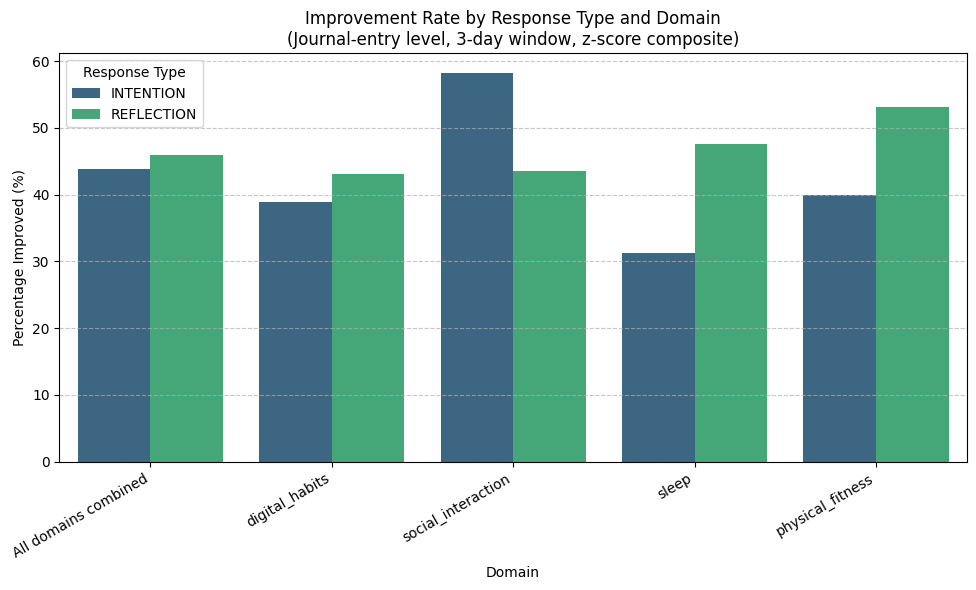

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = pd.DataFrame([overall] + domain_results)

plot_pct = plot_df[["label","intention_pct","reflection_pct"]].melt(
    id_vars="label", var_name="Group", value_name="Percentage Improved"
)
plot_pct["Group"] = plot_pct["Group"].map({"intention_pct":"INTENTION","reflection_pct":"REFLECTION"})

plt.figure(figsize=(10,6))
sns.barplot(x="label", y="Percentage Improved", hue="Group", data=plot_pct, palette="viridis")
plt.title("Improvement Rate by Response Type and Domain\n(Journal-entry level, 3-day window, z-score composite)")
plt.xlabel("Domain")
plt.ylabel("Percentage Improved (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Response Type")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
